In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('monthly_average_BATS_cleaned.csv')
columns_to_drop =['CO2_rolling', 'Alkalinity_rolling']
df = df.drop(columns=columns_to_drop)
df['Alkalinity_category'] = df['Alkalinity'].apply(lambda x: 'Low' if x < 2375 else 'High')
df.head()

,year_month,depth,Temperature,Salinity,Oxygen_1,CO2,Alkalinity,NO3_plus_NO2,NO2,PO4,Silicate,POC,PON,TOC,Bact_Enum,year,Alkalinity_category
0,1992-01-01,690.000000,15.565125,35.958723,225.854167,2056.258333,2398.263636,8.589375,0.083750,0.563542,8.352292,16.452188,3.523438,54.4,3.410000,1992,High
1,1992-02-01,585.584146,15.657915,35.998205,228.434091,2061.666667,2377.966667,8.487778,0.097381,0.556222,8.052222,13.292000,3.275000,54.4,3.951724,1992,High
2,1992-03-01,683.216667,15.043264,35.967208,227.029167,2062.550000,2392.100000,8.546596,0.036190,0.585745,8.768750,14.677188,3.524062,54.4,4.044444,1992,High
3,1992-04-01,606.393976,15.876349,36.027600,227.782222,2070.208333,2394.225000,8.256889,0.044889,0.525814,7.562000,19.444333,4.285667,54.4,4.230000,1992,High
4,1992-05-01,681.927778,15.662847,36.023271,228.402083,2068.016667,2392.408333,8.326667,0.008958,0.575000,7.776458,19.150000,4.015000,54.4,4.441667,1992,High


In [3]:
feature_columns = ["depth", "Temperature", "Salinity", "Oxygen_1", "CO2", 
                  "NO3_plus_NO2", "NO2", "PO4", "Silicate", "POC", "PON", "TOC", "Bact_Enum"]
target_column = "Alkalinity_category"

X = df[feature_columns]
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

In [4]:
# Create and train Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=0, max_depth=10)

# Train the classifier
dt_classifier.fit(X_train, y_train)

# Make predictions
y_pred = dt_classifier.predict(X_test)
y_pred_proba = dt_classifier.predict_proba(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Classifier Results:")
print("=" * 40)
print(f"Accuracy: {accuracy:.4f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Print confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Calculate and display AUC score
y_test_binary = (y_test == 'High').astype(int)
y_proba_high = y_pred_proba[:, 1]  # Probability of 'High' class
auc_score = roc_auc_score(y_test_binary, y_proba_high)
print(f"\nAUC Score: {auc_score:.4f}")

# Show prediction probabilities for first 10 test samples
print("\nPrediction probabilities for first 10 test samples:")
print("Actual | Predicted | Prob(Low) | Prob(High)")
print("-" * 45)
for i in range(min(10, len(y_test))):
    actual = y_test.iloc[i]
    predicted = y_pred[i]
    prob_low = y_pred_proba[i][0]
    prob_high = y_pred_proba[i][1]
    print(f"{actual:6} | {predicted:9} | {prob_low:.3f}     | {prob_high:.3f}")

Decision Tree Classifier Results:
Accuracy: 0.9737

Classification Report:
              precision    recall  f1-score   support

        High       0.98      0.98      0.98        55
         Low       0.95      0.95      0.95        21

    accuracy                           0.97        76
   macro avg       0.97      0.97      0.97        76
weighted avg       0.97      0.97      0.97        76

Confusion Matrix:
[[54  1]
 [ 1 20]]

AUC Score: 0.0329

Prediction probabilities for first 10 test samples:
Actual | Predicted | Prob(Low) | Prob(High)
---------------------------------------------
High   | High      | 1.000     | 0.000
High   | High      | 1.000     | 0.000
Low    | Low       | 0.000     | 1.000
High   | High      | 1.000     | 0.000
High   | High      | 1.000     | 0.000
High   | High      | 1.000     | 0.000
Low    | Low       | 0.000     | 1.000
High   | High      | 1.000     | 0.000
High   | High      | 1.000     | 0.000
High   | High      | 1.000     | 0.000


Decision tree visualization saved as 'decision_tree_visualization.png'


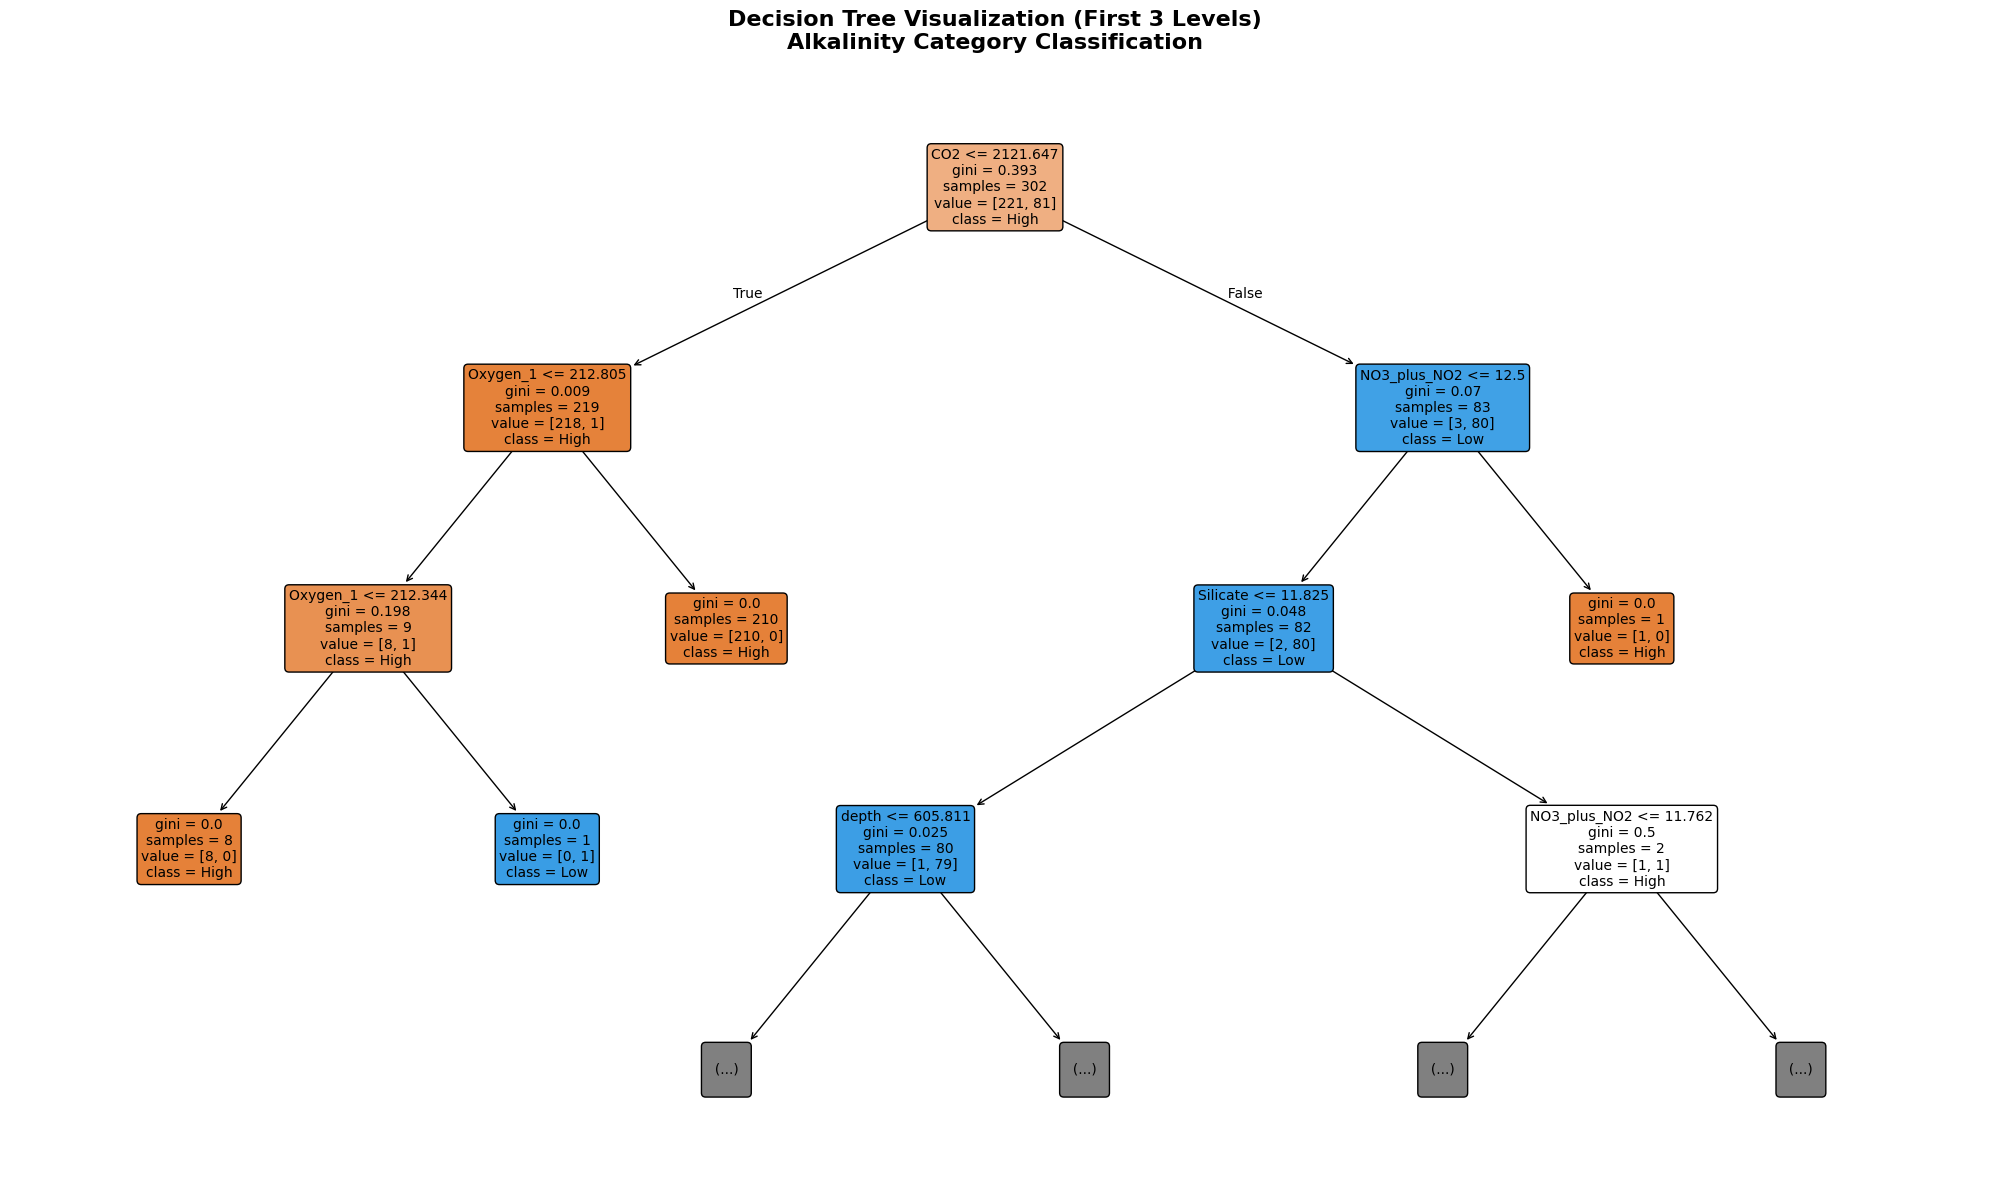


Feature Importance (Decision Tree):
----------------------------------------
CO2             | 0.9344
NO3_plus_NO2    | 0.0243
Oxygen_1        | 0.0168
PO4             | 0.0112
Silicate        | 0.0078
depth           | 0.0054
Salinity        | 0.0000
Temperature     | 0.0000
NO2             | 0.0000
POC             | 0.0000
PON             | 0.0000
TOC             | 0.0000
Bact_Enum       | 0.0000
Feature importance visualization saved as 'decision_tree_feature_importance.png'


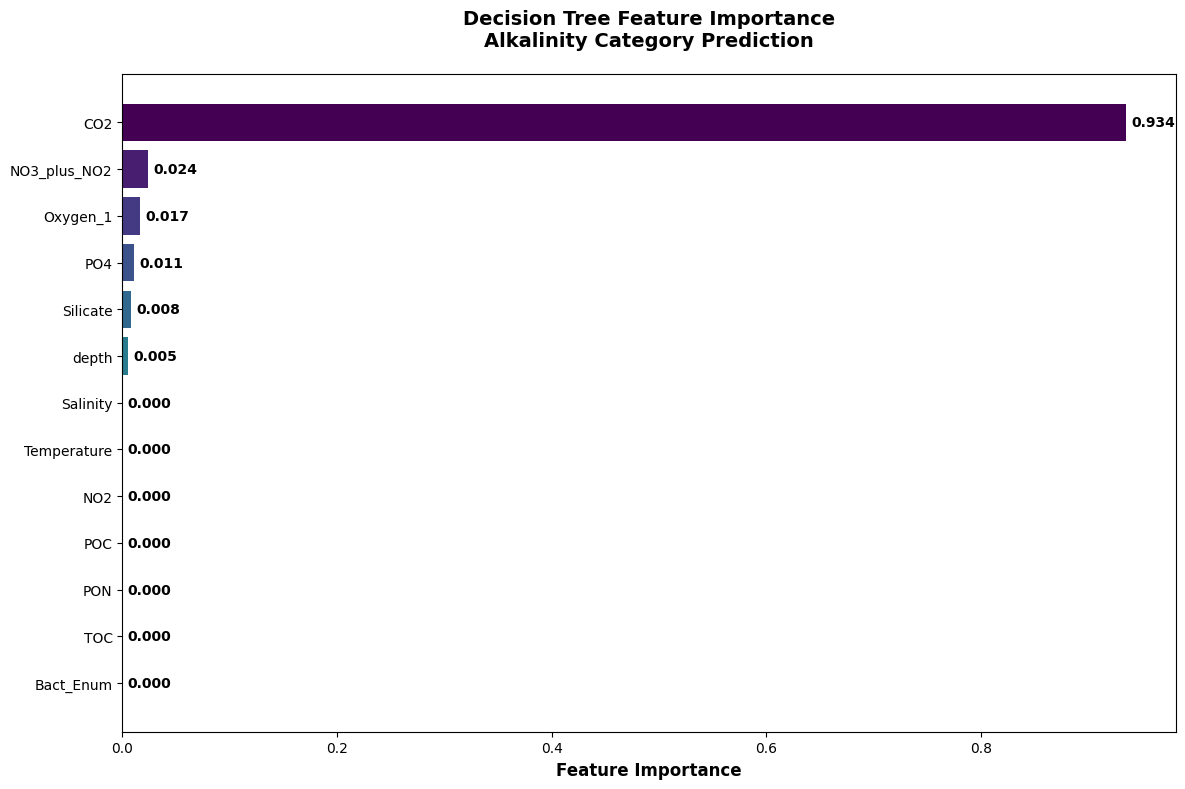


Decision Tree Statistics:
Tree depth: 5
Number of leaves: 9
Number of nodes: 17

Top 5 Most Important Features:
-----------------------------------
1. CO2 (0.934)
2. NO3_plus_NO2 (0.024)
3. Oxygen_1 (0.017)
4. PO4 (0.011)
5. Silicate (0.008)


In [5]:
# Visualize the Decision Tree
plt.figure(figsize=(20, 12))
plot_tree(dt_classifier, 
          max_depth=3,  # Show only first 3 levels for readability
          feature_names=feature_columns,
          class_names=['High', 'Low'],
          filled=True,
          rounded=True,
          fontsize=10)

plt.title('Decision Tree Visualization (First 3 Levels)\nAlkalinity Category Classification', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('decision_tree_visualization.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
print("Decision tree visualization saved as 'decision_tree_visualization.png'")
plt.show()

# Feature Importance Analysis
feature_importance = dt_classifier.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nFeature Importance (Decision Tree):")
print("-" * 40)
for i, row in importance_df.iterrows():
    print(f"{row['Feature']:15} | {row['Importance']:.4f}")

# Visualize Feature Importance
plt.figure(figsize=(12, 8))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], 
                color=plt.cm.viridis(np.linspace(0, 1, len(importance_df))))
plt.xlabel('Feature Importance', fontweight='bold', fontsize=12)
plt.title('Decision Tree Feature Importance\nAlkalinity Category Prediction', 
          fontweight='bold', fontsize=14, pad=20)
plt.gca().invert_yaxis()

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, importance_df['Importance'])):
    plt.text(value + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{value:.3f}', ha='left', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('decision_tree_feature_importance.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
print("Feature importance visualization saved as 'decision_tree_feature_importance.png'")
plt.show()

# Tree Statistics
print(f"\nDecision Tree Statistics:")
print(f"Tree depth: {dt_classifier.get_depth()}")
print(f"Number of leaves: {dt_classifier.get_n_leaves()}")
print(f"Number of nodes: {dt_classifier.tree_.node_count}")

# Top 5 most important features
print(f"\nTop 5 Most Important Features:")
print("-" * 35)
for i in range(min(5, len(importance_df))):
    row = importance_df.iloc[i]
    print(f"{i+1}. {row['Feature']} ({row['Importance']:.3f})")

Decision Tree confusion matrix saved as 'decision_tree_confusion_matrix.png'


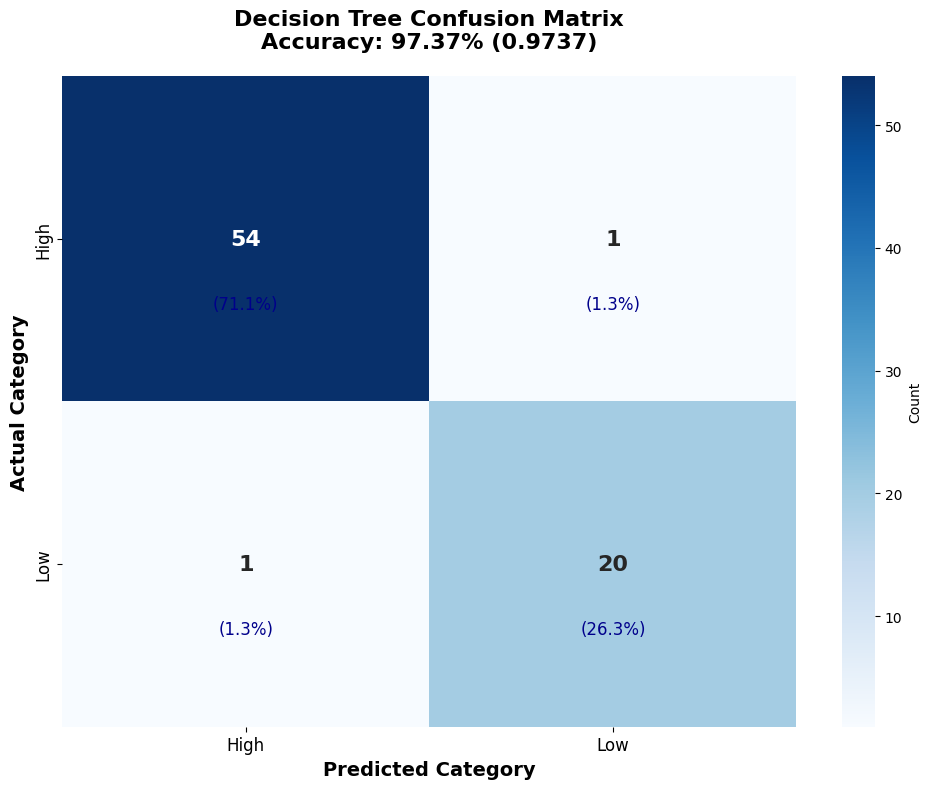


Confusion Matrix Analysis:
True Positives (High predicted as High): 54
False Negatives (High predicted as Low): 1
False Positives (Low predicted as High): 1
True Negatives (Low predicted as Low): 20

Total Test Samples: 76
Correct Predictions: 74
Incorrect Predictions: 2
Model Accuracy: 0.9737 (97.37%)


In [6]:
# Create Confusion Matrix Visualization
import seaborn as sns

plt.figure(figsize=(10, 8))

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['High', 'Low']

# Create heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 16, 'weight': 'bold'})

plt.title(f'Decision Tree Confusion Matrix\nAccuracy: {accuracy:.2%} ({accuracy:.4f})', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Category', fontsize=14, fontweight='bold')
plt.ylabel('Actual Category', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=12)

# Add text annotations with percentages
total_samples = np.sum(cm)
for i in range(len(labels)):
    for j in range(len(labels)):
        count = cm[i, j]
        percentage = count / total_samples * 100
        plt.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)', 
                ha='center', va='center', fontsize=12, color='darkblue')

plt.tight_layout()
plt.savefig('decision_tree_confusion_matrix.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
print("Decision Tree confusion matrix saved as 'decision_tree_confusion_matrix.png'")
plt.show()

# Print detailed confusion matrix analysis
print("\nConfusion Matrix Analysis:")
print("=" * 50)
print(f"True Positives (High predicted as High): {cm[0][0]}")
print(f"False Negatives (High predicted as Low): {cm[0][1]}")
print(f"False Positives (Low predicted as High): {cm[1][0]}")
print(f"True Negatives (Low predicted as Low): {cm[1][1]}")
print(f"\nTotal Test Samples: {total_samples}")
print(f"Correct Predictions: {cm[0][0] + cm[1][1]}")
print(f"Incorrect Predictions: {cm[0][1] + cm[1][0]}")
print(f"Model Accuracy: {accuracy:.4f} ({accuracy:.2%})")

In [7]:
# Hyperparameter Tuning - Create Additional Decision Trees
from sklearn.model_selection import GridSearchCV

print("Hyperparameter Tuning for Decision Trees")
print("=" * 50)

# Define parameter grids for different tree configurations
param_grid_1 = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grid_2 = {
    'max_depth': [15, 20, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

# First hyperparameter-tuned model (shallow trees focus)
print("\n1. Tuning Decision Tree #2 (Shallow Tree Focus):")
print("-" * 45)
dt_classifier_2 = DecisionTreeClassifier(random_state=0)
grid_search_1 = GridSearchCV(dt_classifier_2, param_grid_1, cv=5, 
                            scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_1.fit(X_train, y_train)

print(f"Best parameters for Tree #2: {grid_search_1.best_params_}")
print(f"Best cross-validation score: {grid_search_1.best_score_:.4f}")

# Second hyperparameter-tuned model (deep trees focus)
print("\n2. Tuning Decision Tree #3 (Deep Tree Focus):")
print("-" * 45)
dt_classifier_3 = DecisionTreeClassifier(random_state=0)
grid_search_2 = GridSearchCV(dt_classifier_3, param_grid_2, cv=5, 
                            scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_2.fit(X_train, y_train)

print(f"Best parameters for Tree #3: {grid_search_2.best_params_}")
print(f"Best cross-validation score: {grid_search_2.best_score_:.4f}")

# Get the best models
best_dt_2 = grid_search_1.best_estimator_
best_dt_3 = grid_search_2.best_estimator_

Hyperparameter Tuning for Decision Trees

1. Tuning Decision Tree #2 (Shallow Tree Focus):
---------------------------------------------
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for Tree #2: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best cross-validation score: 0.9769

2. Tuning Decision Tree #3 (Deep Tree Focus):
---------------------------------------------
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters for Tree #3: {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best cross-validation score: 0.9834


In [8]:
# Evaluate and Compare All Three Decision Tree Models
print("\nModel Comparison - All Three Decision Trees")
print("=" * 60)

# Make predictions with all three models
models = {
    'Original Tree (max_depth=10)': dt_classifier,
    'Tuned Tree #2 (Shallow Focus)': best_dt_2,
    'Tuned Tree #3 (Deep Focus)': best_dt_3
}

results = {}

for name, model in models.items():
    # Make predictions
    y_pred_model = model.predict(X_test)
    y_pred_proba_model = model.predict_proba(X_test)
    
    # Calculate metrics
    accuracy_model = accuracy_score(y_test, y_pred_model)
    cm_model = confusion_matrix(y_test, y_pred_model)
    
    # Calculate AUC
    y_proba_high_model = y_pred_proba_model[:, 1]
    auc_model = roc_auc_score(y_test_binary, y_proba_high_model)
    
    # Store results
    results[name] = {
        'accuracy': accuracy_model,
        'confusion_matrix': cm_model,
        'auc': auc_model,
        'depth': model.get_depth(),
        'n_leaves': model.get_n_leaves(),
        'n_nodes': model.tree_.node_count,
        'model': model
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy_model:.4f} ({accuracy_model:.2%})")
    print(f"  AUC Score: {auc_model:.4f}")
    print(f"  Tree Depth: {model.get_depth()}")
    print(f"  Number of Leaves: {model.get_n_leaves()}")
    print(f"  Number of Nodes: {model.tree_.node_count}")
    print(f"  Confusion Matrix:")
    print(f"    TP: {cm_model[0][0]}, FN: {cm_model[0][1]}")
    print(f"    FP: {cm_model[1][0]}, TN: {cm_model[1][1]}")

# Create comparison summary
print(f"\n{'Model Comparison Summary'}")
print("=" * 60)
print(f"{'Model':<30} {'Accuracy':<10} {'AUC':<8} {'Depth':<6} {'Leaves':<7} {'Nodes'}")
print("-" * 60)
for name, result in results.items():
    print(f"{name:<30} {result['accuracy']:.4f}    {result['auc']:.4f}  {result['depth']:<6} {result['n_leaves']:<7} {result['n_nodes']}")

# Find best model
best_model_name = max(results.keys(), key=lambda k: results[k]['accuracy'])
print(f"\nBest performing model: {best_model_name}")
print(f"Best accuracy: {results[best_model_name]['accuracy']:.4f}")

# Store models for later visualization
dt_models = results


Model Comparison - All Three Decision Trees

Original Tree (max_depth=10):
  Accuracy: 0.9737 (97.37%)
  AUC Score: 0.0329
  Tree Depth: 5
  Number of Leaves: 9
  Number of Nodes: 17
  Confusion Matrix:
    TP: 54, FN: 1
    FP: 1, TN: 20

Tuned Tree #2 (Shallow Focus):
  Accuracy: 0.9737 (97.37%)
  AUC Score: 0.0333
  Tree Depth: 3
  Number of Leaves: 5
  Number of Nodes: 9
  Confusion Matrix:
    TP: 54, FN: 1
    FP: 1, TN: 20

Tuned Tree #3 (Deep Focus):
  Accuracy: 0.9737 (97.37%)
  AUC Score: 0.0346
  Tree Depth: 2
  Number of Leaves: 4
  Number of Nodes: 7
  Confusion Matrix:
    TP: 54, FN: 1
    FP: 1, TN: 20

Model Comparison Summary
Model                          Accuracy   AUC      Depth  Leaves  Nodes
------------------------------------------------------------
Original Tree (max_depth=10)   0.9737    0.0329  5      9       17
Tuned Tree #2 (Shallow Focus)  0.9737    0.0333  3      5       9
Tuned Tree #3 (Deep Focus)     0.9737    0.0346  2      4       7

Best performin

C:\Users\themo\AppData\Local\Temp\ipykernel_36516\198329128.py:106: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


Decision trees comparison visualization saved as 'decision_trees_comparison.png'


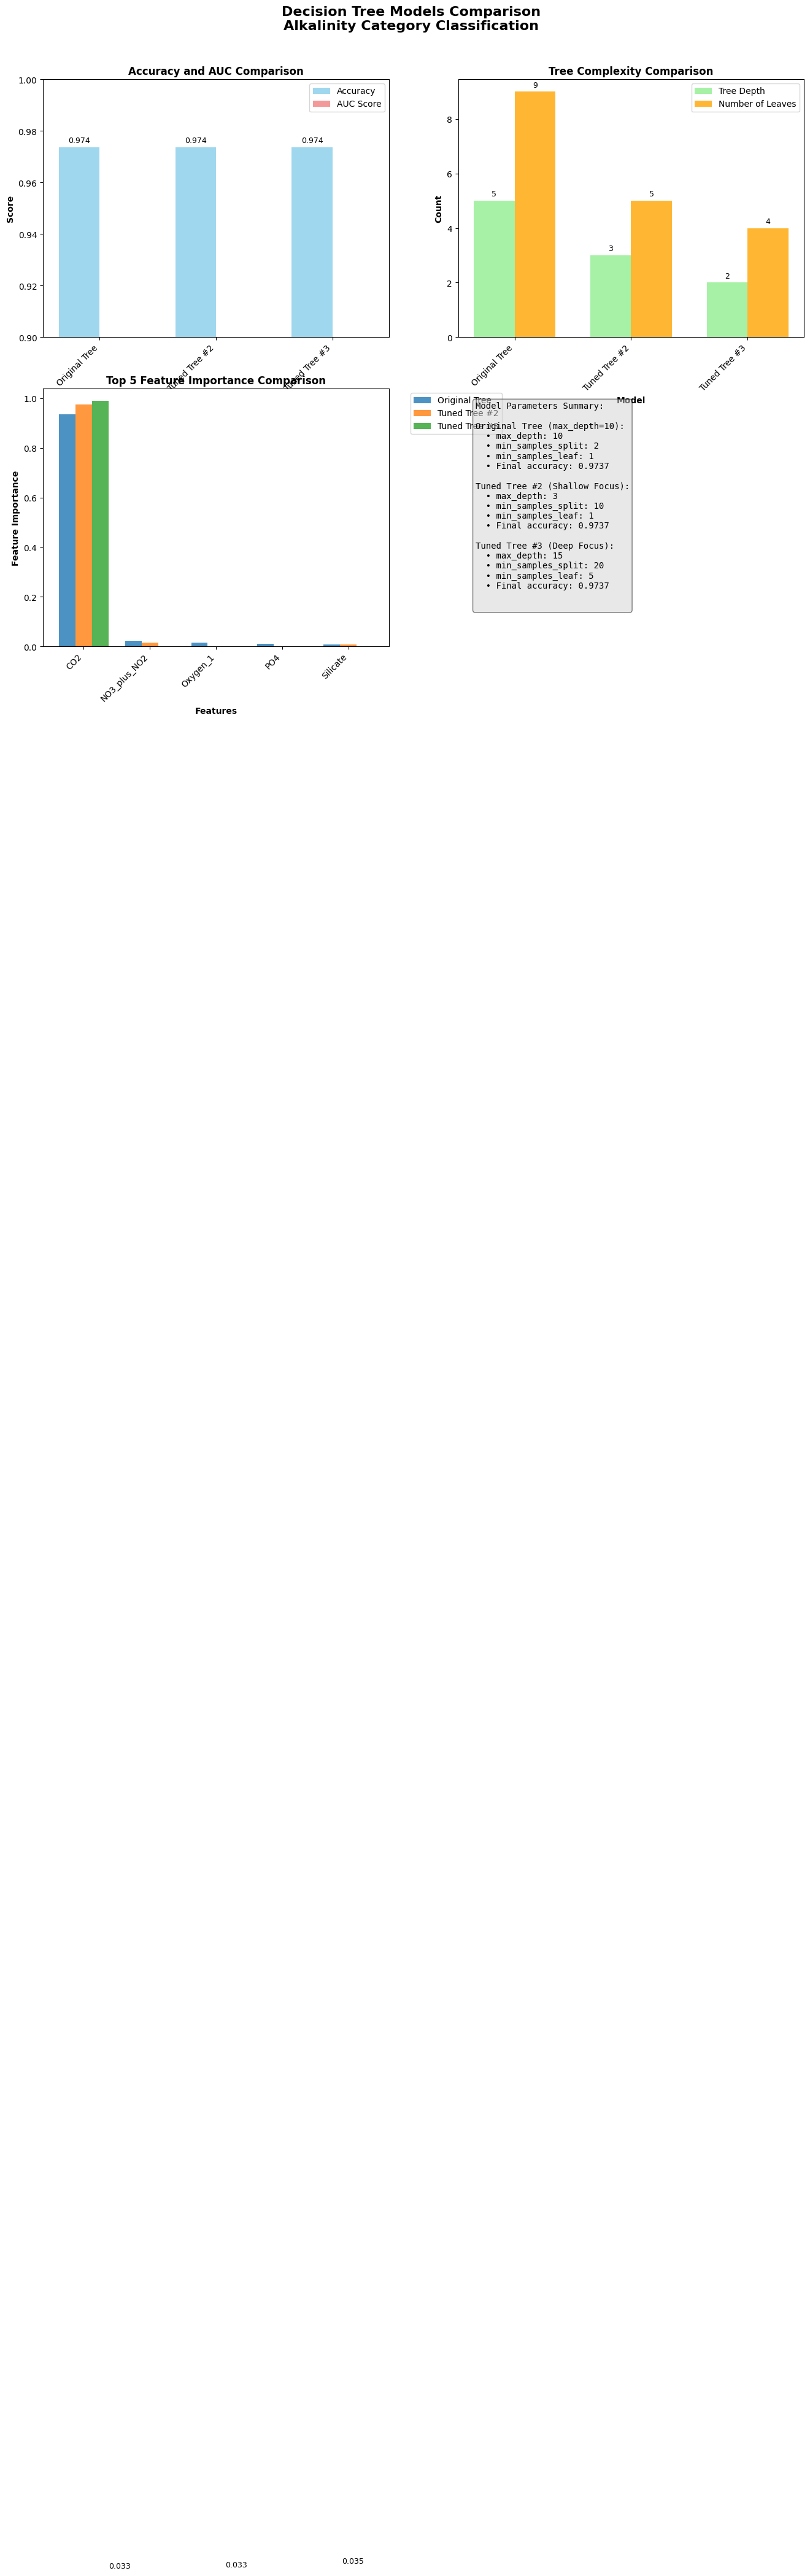

In [9]:
# Visualize Comparison of All Three Decision Tree Models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Decision Tree Models Comparison\nAlkalinity Category Classification', 
             fontsize=16, fontweight='bold', y=0.98)

# Model performance comparison (bar chart)
ax1 = axes[0, 0]
model_names = list(dt_models.keys())
accuracies = [dt_models[name]['accuracy'] for name in model_names]
auc_scores = [dt_models[name]['auc'] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax1.bar(x - width/2, accuracies, width, label='Accuracy', alpha=0.8, color='skyblue')
bars2 = ax1.bar(x + width/2, auc_scores, width, label='AUC Score', alpha=0.8, color='lightcoral')

ax1.set_xlabel('Model', fontweight='bold')
ax1.set_ylabel('Score', fontweight='bold')
ax1.set_title('Accuracy and AUC Comparison', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([name.split('(')[0].strip() for name in model_names], rotation=45, ha='right')
ax1.legend()
ax1.set_ylim(0.9, 1.0)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Tree complexity comparison
ax2 = axes[0, 1]
depths = [dt_models[name]['depth'] for name in model_names]
n_leaves = [dt_models[name]['n_leaves'] for name in model_names]

bars3 = ax2.bar(x - width/2, depths, width, label='Tree Depth', alpha=0.8, color='lightgreen')
bars4 = ax2.bar(x + width/2, n_leaves, width, label='Number of Leaves', alpha=0.8, color='orange')

ax2.set_xlabel('Model', fontweight='bold')
ax2.set_ylabel('Count', fontweight='bold')
ax2.set_title('Tree Complexity Comparison', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([name.split('(')[0].strip() for name in model_names], rotation=45, ha='right')
ax2.legend()

# Add value labels
for bar in bars3:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)
for bar in bars4:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)

# Feature importance comparison for top 5 features
ax3 = axes[1, 0]
feature_importances = {}
for name, result in dt_models.items():
    importance = result['model'].feature_importances_
    feature_importances[name] = importance

# Get top 5 features from original model
top_5_indices = np.argsort(dt_classifier.feature_importances_)[-5:][::-1]
top_5_features = [feature_columns[i] for i in top_5_indices]

x_feat = np.arange(len(top_5_features))
width_feat = 0.25

for i, (name, importance) in enumerate(feature_importances.items()):
    top_5_importance = [importance[idx] for idx in top_5_indices]
    ax3.bar(x_feat + i*width_feat, top_5_importance, width_feat, 
            label=name.split('(')[0].strip(), alpha=0.8)

ax3.set_xlabel('Features', fontweight='bold')
ax3.set_ylabel('Feature Importance', fontweight='bold')
ax3.set_title('Top 5 Feature Importance Comparison', fontweight='bold')
ax3.set_xticks(x_feat + width_feat)
ax3.set_xticklabels(top_5_features, rotation=45, ha='right')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Model parameters summary
ax4 = axes[1, 1]
ax4.axis('off')
summary_text = "Model Parameters Summary:\n\n"

for name, result in dt_models.items():
    model = result['model']
    summary_text += f"{name}:\n"
    summary_text += f"  • max_depth: {model.max_depth}\n"
    summary_text += f"  • min_samples_split: {model.min_samples_split}\n"
    summary_text += f"  • min_samples_leaf: {model.min_samples_leaf}\n"
    if hasattr(model, 'max_features') and model.max_features is not None:
        summary_text += f"  • max_features: {model.max_features}\n"
    summary_text += f"  • Final accuracy: {result['accuracy']:.4f}\n\n"

ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.5))

plt.tight_layout()
plt.savefig('decision_trees_comparison.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
print("Decision trees comparison visualization saved as 'decision_trees_comparison.png'")
plt.show()

Tree complexity comparison saved as 'decision_tree_complexity_comparison.png'


<Figure size 1400x800 with 0 Axes>

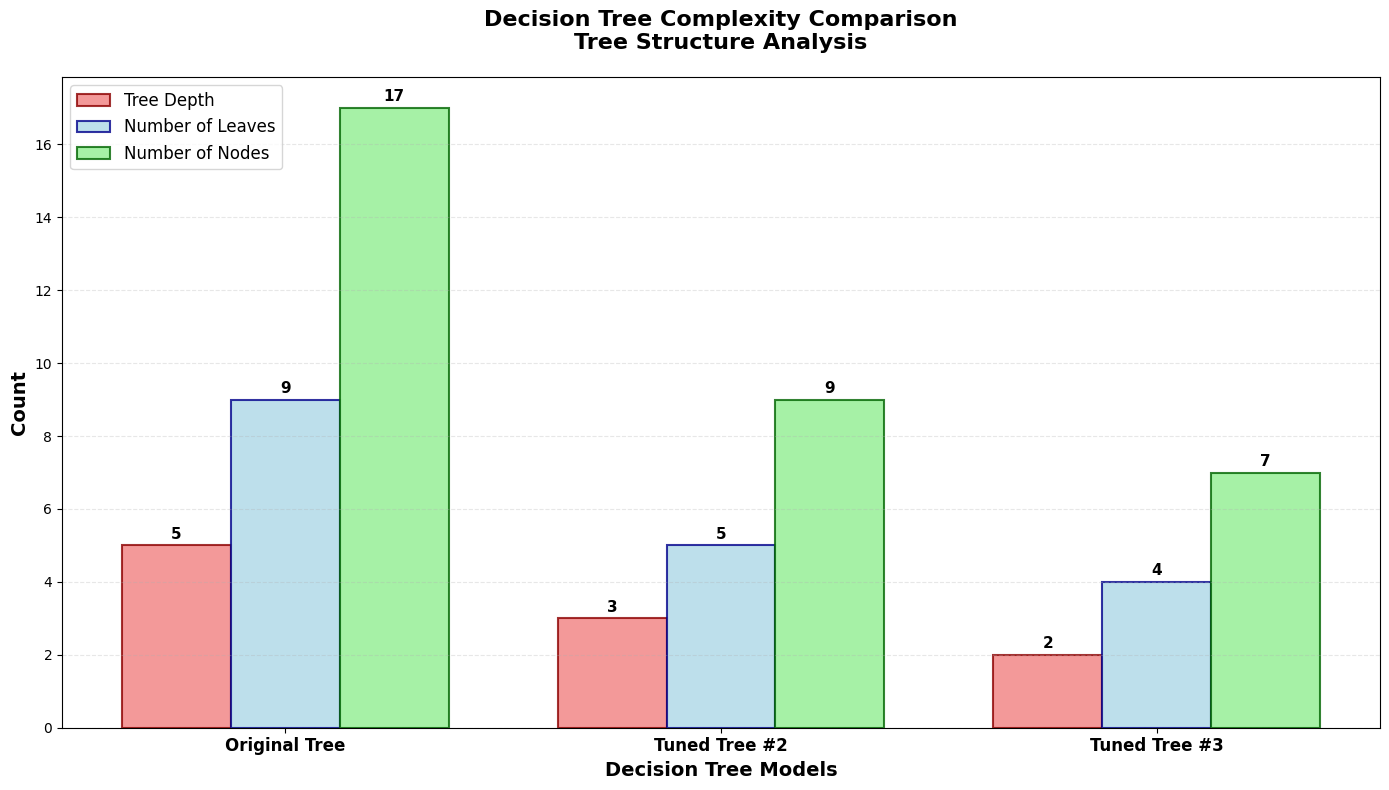


Detailed Tree Complexity Metrics:
Model                          Depth  Leaves   Nodes  Complexity*
------------------------------------------------------------
Original Tree                  5      9        17     1.89
Tuned Tree #2                  3      5        9      1.80
Tuned Tree #3                  2      4        7      1.75

*Complexity = Nodes/Leaves ratio (lower = simpler)

Simplest model: Tuned Tree #3 (7 nodes)
Most complex model: Original Tree (17 nodes)


In [11]:
# Isolated Tree Complexity Comparison
plt.figure(figsize=(14, 8))

# Get model data
model_names = list(dt_models.keys())
depths = [dt_models[name]['depth'] for name in model_names]
n_leaves = [dt_models[name]['n_leaves'] for name in model_names]
n_nodes = [dt_models[name]['n_nodes'] for name in model_names]

# Clean model names for display
clean_names = [name.split('(')[0].strip() for name in model_names]

# Create subplot with two y-axes
fig, ax1 = plt.subplots(figsize=(14, 8))

# Bar positions
x = np.arange(len(model_names))
width = 0.25

# Plot bars for depth and leaves on primary y-axis
bars1 = ax1.bar(x - width, depths, width, label='Tree Depth', 
                alpha=0.8, color='lightcoral', edgecolor='darkred', linewidth=1.5)
bars2 = ax1.bar(x, n_leaves, width, label='Number of Leaves', 
                alpha=0.8, color='lightblue', edgecolor='darkblue', linewidth=1.5)
bars3 = ax1.bar(x + width, n_nodes, width, label='Number of Nodes', 
                alpha=0.8, color='lightgreen', edgecolor='darkgreen', linewidth=1.5)

# Customize primary y-axis
ax1.set_xlabel('Decision Tree Models', fontweight='bold', fontsize=14)
ax1.set_ylabel('Count', fontweight='bold', fontsize=14)
ax1.set_title('Decision Tree Complexity Comparison\nTree Structure Analysis', 
              fontweight='bold', fontsize=16, pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(clean_names, fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=12)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                 f'{int(height)}', ha='center', va='bottom', 
                 fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('decision_tree_complexity_comparison.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
print("Tree complexity comparison saved as 'decision_tree_complexity_comparison.png'")
plt.show()

# Print detailed complexity metrics
print("\nDetailed Tree Complexity Metrics:")
print("=" * 60)
print(f"{'Model':<30} {'Depth':<6} {'Leaves':<8} {'Nodes':<6} {'Complexity*'}")
print("-" * 60)
for i, name in enumerate(model_names):
    complexity_ratio = n_nodes[i] / n_leaves[i]
    print(f"{clean_names[i]:<30} {depths[i]:<6} {n_leaves[i]:<8} {n_nodes[i]:<6} {complexity_ratio:.2f}")

print(f"\n*Complexity = Nodes/Leaves ratio (lower = simpler)")
print(f"\nSimplest model: {clean_names[np.argmin(n_nodes)]} ({min(n_nodes)} nodes)")
print(f"Most complex model: {clean_names[np.argmax(n_nodes)]} ({max(n_nodes)} nodes)")

All three decision trees visualization saved as 'all_three_decision_trees.png'


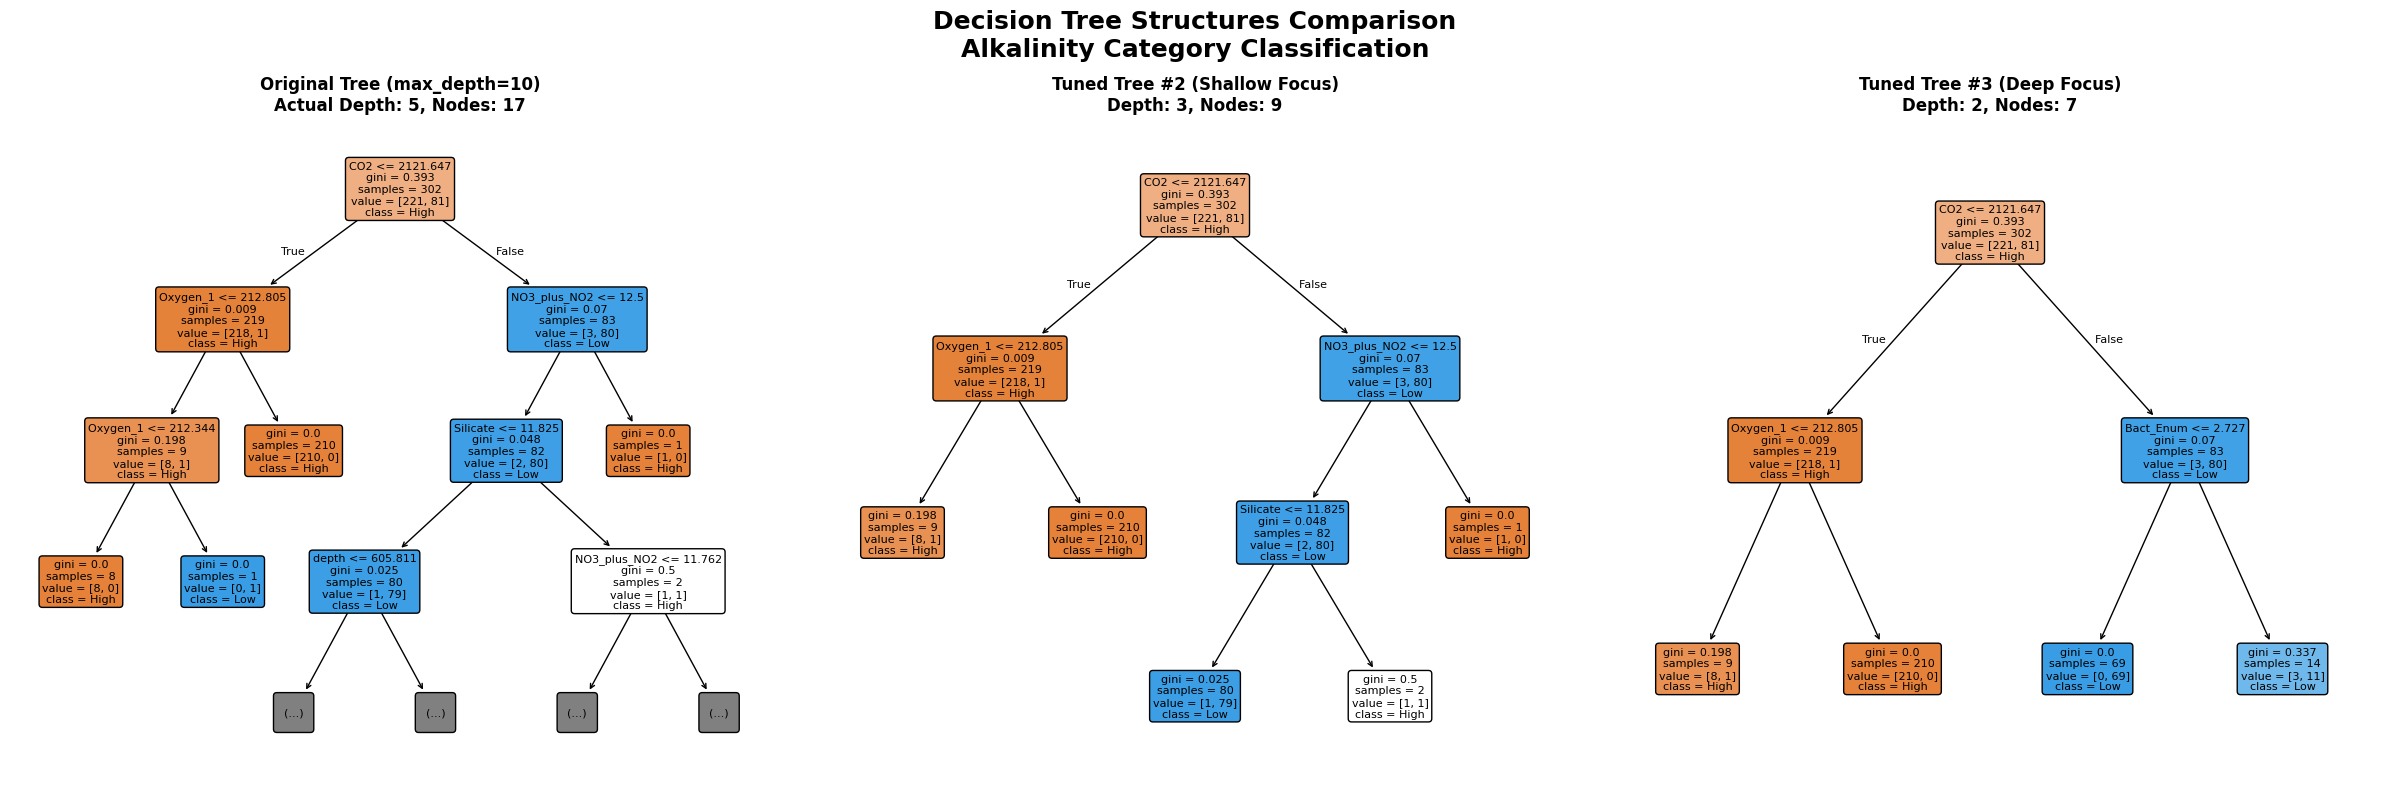


Tree Structure Details:

Original Tree:
  Parameters:
    • max_depth: 10
    • min_samples_split: 2
    • min_samples_leaf: 1
  Structure:
    • Actual depth: 5
    • Number of leaves: 9
    • Total nodes: 17
  Performance:
    • Test accuracy: 0.9737 (97.37%)

Tuned Tree #2:
  Parameters:
    • max_depth: 3
    • min_samples_split: 10
    • min_samples_leaf: 1
  Structure:
    • Actual depth: 3
    • Number of leaves: 5
    • Total nodes: 9
  Performance:
    • Test accuracy: 0.9737 (97.37%)

Tuned Tree #3:
  Parameters:
    • max_depth: 15
    • min_samples_split: 20
    • min_samples_leaf: 5
  Structure:
    • Actual depth: 2
    • Number of leaves: 4
    • Total nodes: 7
  Performance:
    • Test accuracy: 0.9737 (97.37%)


In [12]:
# Visualize All Three Decision Trees
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('Decision Tree Structures Comparison\nAlkalinity Category Classification', 
             fontsize=18, fontweight='bold', y=0.98)

# Tree 1: Original Tree
ax1 = axes[0]
plt.sca(ax1)
plot_tree(dt_classifier, 
          max_depth=3,  # Show first 3 levels for consistency
          feature_names=feature_columns,
          class_names=['High', 'Low'],
          filled=True,
          rounded=True,
          fontsize=8)
ax1.set_title('Original Tree (max_depth=10)\nActual Depth: 5, Nodes: 17', 
              fontsize=12, fontweight='bold', pad=10)

# Tree 2: Tuned Tree #2 (Shallow Focus)
ax2 = axes[1]
plt.sca(ax2)
plot_tree(best_dt_2, 
          max_depth=3,  # This tree is only 3 levels deep anyway
          feature_names=feature_columns,
          class_names=['High', 'Low'],
          filled=True,
          rounded=True,
          fontsize=8)
ax2.set_title('Tuned Tree #2 (Shallow Focus)\nDepth: 3, Nodes: 9', 
              fontsize=12, fontweight='bold', pad=10)

# Tree 3: Tuned Tree #3 (Deep Focus)
ax3 = axes[2]
plt.sca(ax3)
plot_tree(best_dt_3, 
          max_depth=None,  # Show full tree since it's only 2 levels
          feature_names=feature_columns,
          class_names=['High', 'Low'],
          filled=True,
          rounded=True,
          fontsize=8)
ax3.set_title('Tuned Tree #3 (Deep Focus)\nDepth: 2, Nodes: 7', 
              fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('all_three_decision_trees.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
print("All three decision trees visualization saved as 'all_three_decision_trees.png'")
plt.show()

# Print tree structure comparison
print("\nTree Structure Details:")
print("=" * 70)

trees_info = [
    ("Original Tree", dt_classifier),
    ("Tuned Tree #2", best_dt_2),
    ("Tuned Tree #3", best_dt_3)
]

for name, model in trees_info:
    print(f"\n{name}:")
    print(f"  Parameters:")
    print(f"    • max_depth: {model.max_depth}")
    print(f"    • min_samples_split: {model.min_samples_split}")
    print(f"    • min_samples_leaf: {model.min_samples_leaf}")
    if hasattr(model, 'max_features') and model.max_features is not None:
        print(f"    • max_features: {model.max_features}")
    print(f"  Structure:")
    print(f"    • Actual depth: {model.get_depth()}")
    print(f"    • Number of leaves: {model.get_n_leaves()}")
    print(f"    • Total nodes: {model.tree_.node_count}")
    print(f"  Performance:")
    accuracy_temp = accuracy_score(y_test, model.predict(X_test))
    print(f"    • Test accuracy: {accuracy_temp:.4f} ({accuracy_temp:.2%})")

Tuned Tree #2 confusion matrix saved as 'tuned_tree2_confusion_matrix.png'


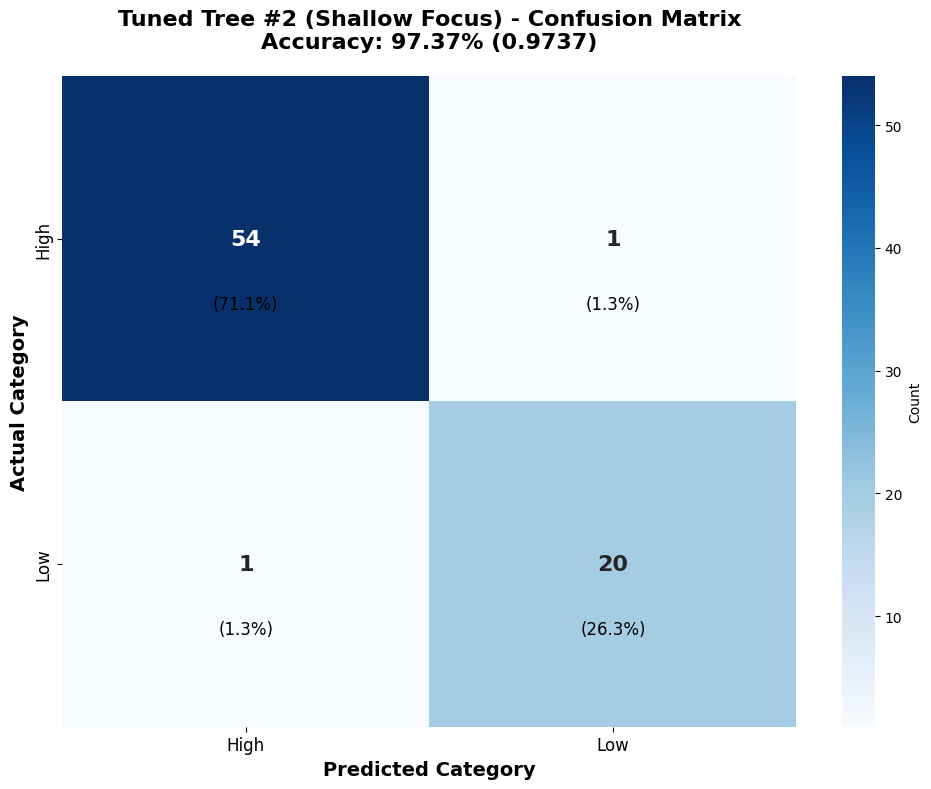


Tuned Tree #2 Confusion Matrix Analysis:
True Positives (High predicted as High): 54
False Negatives (High predicted as Low): 1
False Positives (Low predicted as High): 1
True Negatives (Low predicted as Low): 20
Model Accuracy: 0.9737 (97.37%)


Tuned Tree #3 confusion matrix saved as 'tuned_tree3_confusion_matrix.png'
Tuned Tree #3 confusion matrix saved as 'tuned_tree3_confusion_matrix.png'


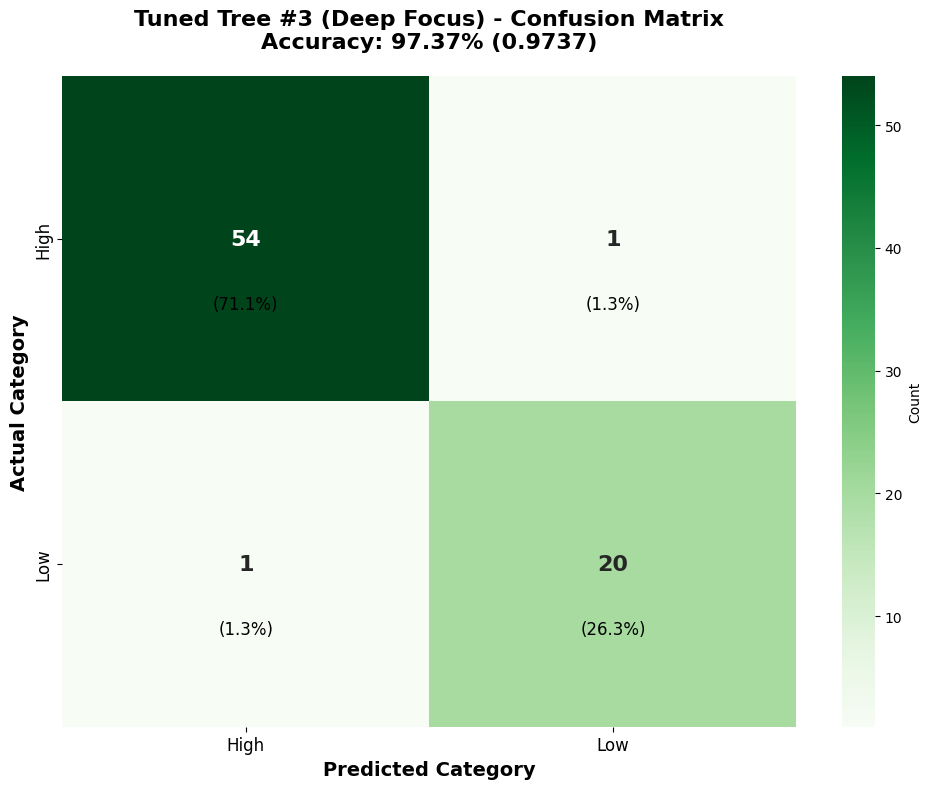

Tuned Tree #3 Confusion Matrix Analysis:
True Positives (High predicted as High): 54
False Negatives (High predicted as Low): 1
False Positives (Low predicted as High): 1
True Negatives (Low predicted as Low): 20
Model Accuracy: 0.9737 (97.37%)

COMPARISON OF ALL THREE MODELS:
Model                     TP   FN   FP   TN   Accuracy
----------------------------------------------------------------------
Original Tree             54   1    1    20   0.9737
Tuned Tree #2             54   1    1    20   0.9737
Tuned Tree #3             54   1    1    20   0.9737

All three models show identical performance with the same confusion matrix values.


In [14]:
# Create Separate Confusion Matrices for Tuned Trees
import seaborn as sns

# Tuned Tree #2 Confusion Matrix
plt.figure(figsize=(10, 8))

# Get predictions and confusion matrix for Tree #2
y_pred_tree2 = best_dt_2.predict(X_test)
cm_tree2 = confusion_matrix(y_test, y_pred_tree2)
accuracy_tree2 = accuracy_score(y_test, y_pred_tree2)
labels = ['High', 'Low']

# Create heatmap for Tree #2
sns.heatmap(cm_tree2, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 16, 'weight': 'bold'})

plt.title(f'Tuned Tree #2 (Shallow Focus) - Confusion Matrix\nAccuracy: {accuracy_tree2:.2%} ({accuracy_tree2:.4f})', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Category', fontsize=14, fontweight='bold')
plt.ylabel('Actual Category', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=12)

# Add text annotations with percentages
total_samples_tree2 = np.sum(cm_tree2)
for i in range(len(labels)):
    for j in range(len(labels)):
        count = cm_tree2[i, j]
        percentage = count / total_samples_tree2 * 100
        plt.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)', 
                ha='center', va='center', fontsize=12, color='black')

plt.tight_layout()
plt.savefig('tuned_tree2_confusion_matrix.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
print("Tuned Tree #2 confusion matrix saved as 'tuned_tree2_confusion_matrix.png'")
plt.show()

# Print analysis for Tree #2
print("\nTuned Tree #2 Confusion Matrix Analysis:")
print("=" * 50)
print(f"True Positives (High predicted as High): {cm_tree2[0][0]}")
print(f"False Negatives (High predicted as Low): {cm_tree2[0][1]}")
print(f"False Positives (Low predicted as High): {cm_tree2[1][0]}")
print(f"True Negatives (Low predicted as Low): {cm_tree2[1][1]}")
print(f"Model Accuracy: {accuracy_tree2:.4f} ({accuracy_tree2:.2%})")

print("\n" + "="*70 + "\n")

# Tuned Tree #3 Confusion Matrix
plt.figure(figsize=(10, 8))

# Get predictions and confusion matrix for Tree #3
y_pred_tree3 = best_dt_3.predict(X_test)
cm_tree3 = confusion_matrix(y_test, y_pred_tree3)
accuracy_tree3 = accuracy_score(y_test, y_pred_tree3)

# Create heatmap for Tree #3
sns.heatmap(cm_tree3, annot=True, fmt='d', cmap='Greens', 
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 16, 'weight': 'bold'})

plt.title(f'Tuned Tree #3 (Deep Focus) - Confusion Matrix\nAccuracy: {accuracy_tree3:.2%} ({accuracy_tree3:.4f})', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Category', fontsize=14, fontweight='bold')
plt.ylabel('Actual Category', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=12)

# Add text annotations with percentages
total_samples_tree3 = np.sum(cm_tree3)
for i in range(len(labels)):
    for j in range(len(labels)):
        count = cm_tree3[i, j]
        percentage = count / total_samples_tree3 * 100
        plt.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)', 
                ha='center', va='center', fontsize=12, color='black')

plt.tight_layout()
plt.savefig('tuned_tree3_confusion_matrix.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
print("Tuned Tree #3 confusion matrix saved as 'tuned_tree3_confusion_matrix.png'")
plt.show()

# Print analysis for Tree #3
print("Tuned Tree #3 Confusion Matrix Analysis:")
print("=" * 50)
print(f"True Positives (High predicted as High): {cm_tree3[0][0]}")
print(f"False Negatives (High predicted as Low): {cm_tree3[0][1]}")
print(f"False Positives (Low predicted as High): {cm_tree3[1][0]}")
print(f"True Negatives (Low predicted as Low): {cm_tree3[1][1]}")
print(f"Model Accuracy: {accuracy_tree3:.4f} ({accuracy_tree3:.2%})")

# Compare all three confusion matrices
print("\n" + "="*70)
print("COMPARISON OF ALL THREE MODELS:")
print("="*70)
print(f"{'Model':<25} {'TP':<4} {'FN':<4} {'FP':<4} {'TN':<4} {'Accuracy'}")
print("-" * 70)
print(f"{'Original Tree':<25} {cm[0][0]:<4} {cm[0][1]:<4} {cm[1][0]:<4} {cm[1][1]:<4} {accuracy:.4f}")
print(f"{'Tuned Tree #2':<25} {cm_tree2[0][0]:<4} {cm_tree2[0][1]:<4} {cm_tree2[1][0]:<4} {cm_tree2[1][1]:<4} {accuracy_tree2:.4f}")
print(f"{'Tuned Tree #3':<25} {cm_tree3[0][0]:<4} {cm_tree3[0][1]:<4} {cm_tree3[1][0]:<4} {cm_tree3[1][1]:<4} {accuracy_tree3:.4f}")
print("\nAll three models show identical performance with the same confusion matrix values.")